## Предсказания TLM для NNCES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [2]:
PREDICTIONS_PATH = "/home/ext-ivanova-mk@ad.speechpro.com/test_dir/tlm/feature_extraction/nnces_titanet_embeddings/nnces_titanet_metadata_with_predictions.csv"
EMB_DIR = "/home/ext-ivanova-mk@ad.speechpro.com/test_dir/tlm/feature_extraction/titanet_embeddings_nnces"

In [3]:
df_pred = pd.read_csv(PREDICTIONS_PATH)
df_pred.head()

,file_path,age,gender,speaker_age,speaker_id,rel_path,embedding_path,embedding_dim,age_pred
0,/home/ext-ivanova-mk@ad.speechpro.com/ITMO/nnc...,10,M,10,M13,10Y/Boys_10/M13/M13_04/M13_04_06.wav,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,27.0
1,/home/ext-ivanova-mk@ad.speechpro.com/ITMO/nnc...,10,M,10,M13,10Y/Boys_10/M13/M13_04/M13_04_05.wav,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,27.0
2,/home/ext-ivanova-mk@ad.speechpro.com/ITMO/nnc...,10,M,10,M13,10Y/Boys_10/M13/M13_04/M13_04_07.wav,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,28.0
3,/home/ext-ivanova-mk@ad.speechpro.com/ITMO/nnc...,10,M,10,M13,10Y/Boys_10/M13/M13_09/M13_09_07.wav,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,28.0
4,/home/ext-ivanova-mk@ad.speechpro.com/ITMO/nnc...,10,M,10,M13,10Y/Boys_10/M13/M13_09/M13_09_01.wav,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,28.0


In [4]:
df_pred['true_age'] = df_pred['age']
df_pred['error'] = df_pred['age_pred'] - df_pred['true_age']
df_pred['abs_error'] = abs(df_pred['error'])
df_pred['squared_error'] = df_pred['error'] ** 2
    
# Основные метрики
MAE = df_pred['abs_error'].mean()
RMSE = np.sqrt(df_pred['squared_error'].mean())
STD_ERROR = df_pred['error'].std()
    
# Процент ошибок в пределах
within_1_year = (df_pred['abs_error'] <= 1).mean() * 100
within_2_years = (df_pred['abs_error'] <= 3).mean() * 100
within_3_years = (df_pred['abs_error'] <= 5).mean() * 100
within_5_years = (df_pred['abs_error'] <= 10).mean() * 100
    
print("\nМетрики оценки TLM модели на NNCES (детские голоса)")
print("\nОсновные метрики:")
print(f"MAE  (Mean Absolute Error):     {MAE:.3f} лет")
print(f"RMSE (Root Mean Squared Error): {RMSE:.3f} лет")
print(f"Std of Error (разброс ошибок):  {STD_ERROR:.3f} лет")
    
print("\nПроцент ошибок в пределах:")
print(f"  ≤ 1 год:   {within_1_year:.1f}%")
print(f"  ≤ 3 года:  {within_2_years:.1f}%")
print(f"  ≤ 5 года:  {within_3_years:.1f}%")
print(f"  ≤ 10 лет:   {within_5_years:.1f}%")
    
print("\nСтатистика абсолютных ошибок:")
print(f"  Мин ошибка:  {df_pred['abs_error'].min():.3f} лет")
print(f"  Медиана:     {df_pred['abs_error'].median():.3f} лет")
print(f"  Макс ошибка: {df_pred['abs_error'].max():.3f} лет")


Метрики оценки TLM модели на NNCES (детские голоса)

Основные метрики:
MAE  (Mean Absolute Error):     20.052 лет
RMSE (Root Mean Squared Error): 20.671 лет
Std of Error (разброс ошибок):  5.023 лет

Процент ошибок в пределах:
  ≤ 1 год:   0.0%
  ≤ 3 года:  0.0%
  ≤ 5 года:  0.0%
  ≤ 10 лет:   0.1%

Статистика абсолютных ошибок:
  Мин ошибка:  9.716 лет
  Медиана:     18.654 лет
  Макс ошибка: 44.264 лет


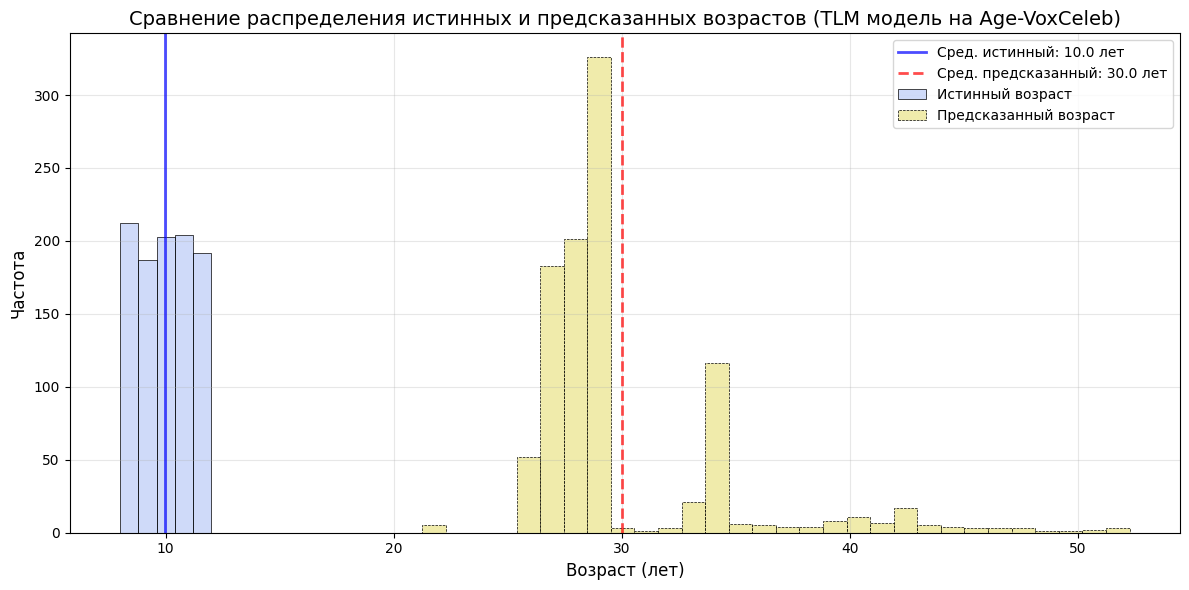

In [8]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_pred, x='true_age', bins=5, 
             color='#A1B7F4', alpha=0.5, label='Истинный возраст',
             edgecolor='black', linewidth=0.5)
sns.histplot(data=df_pred, x='age_pred', bins=30, 
             color="#E3D958", alpha=0.5, label='Предсказанный возраст',
             edgecolor='black', linewidth=0.5, linestyle='--')

plt.axvline(df_pred['true_age'].mean(), color='blue', linestyle='-', linewidth=2, alpha=0.7,
           label=f'Сред. истинный: {df_pred["true_age"].mean():.1f} лет')
plt.axvline(df_pred['age_pred'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Сред. предсказанный: {df_pred["age_pred"].mean():.1f} лет')

plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Сравнение распределения истинных и предсказанных возрастов (TLM модель на Age-VoxCeleb)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()